# Setup ENCODE data
## Correct batch effects
### Author: Martin Loza
### Date: 25/12/16

After selecting the window and genes of interest, we will setup gene pairs for co-expression analysis with ENCODE and GTEx data.

The first step is to correct batch effects and setup genes of interest. In this case we will focus only in genes with a related ENSEMBL ID

In [14]:
# Change R language to English
Sys.setenv(LANGUAGE = "en")

# Init
suppressPackageStartupMessages({
    library(dplyr)
    library(stringr)
    library(ggplot2)
    library(patchwork)
    library(sva)
})

# Local variables 
seed = 777
date = "251216"

# Define colors for strand plots
red = "#E41A1C"
blue = "#090a0bff"
# Define colors for gene types
green = "#4DAF4A"
purple = "#984EA3"
text_size = 18
width = 18.6
dot_size = 4
line_size = 1.5
dpi = 300

data_dir = "/Users/martin/Documents/Projects/lncRNA_TF_pairs_analysis/Data/ENCODE/merged/"
out_dir = "//Users/martin/Documents/Projects/lncRNA_TF_pairs_analysis/06_ENCODE_analyses/Plots/"

# Local Functions


### Load and setup the data

Load the merged normalized data

In [2]:
# load the merged normalized data
merged_normalized <- read.table(paste0(data_dir, "merged_log_normalized_tpm_251216.tsv"), 
                        header = TRUE, sep = "\t", stringsAsFactors = FALSE)

merged_raw <- read.table(paste0(data_dir, "merged_raw_tpm_251216.tsv"), 
                         header = TRUE, sep = "\t", stringsAsFactors = FALSE)
head(merged_normalized)

,gene_id,log_TPM_ENCSR000CUE,log_TPM_ENCSR000AHH,log_TPM_ENCSR000AAQ,log_TPM_ENCSR000AEU,log_TPM_ENCSR000CUF,log_TPM_ENCSR369RVN,log_TPM_ENCSR042GYH,log_TPM_ENCSR146LBD,log_TPM_ENCSR000AAO,⋯,log_TPM_ENCSR719PXC,log_TPM_ENCSR071ZLM,log_TPM_ENCSR000AFL,log_TPM_ENCSR000AEY,log_TPM_ENCSR000AFH,log_TPM_ENCSR000AFO,log_TPM_ENCSR000AFI,log_TPM_ENCSR000AFC,log_TPM_ENCSR000AFB,log_TPM_ENCSR373BDG
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ENSG00000000003,1.6882491,1.3454724,2.83556352,1.8373700,0.708035793,1.80828877,1.8309802,0.587786665,1.0188473,⋯,0.9631743,0.6259384,1.3270750,0.593326845,1.8594181,2.4060438,1.4134230,3.03302806,2.7027026,2.444952334
2,ENSG00000000005,0.0000000,0.0000000,0.00000000,0.0000000,0.000000000,0.01980263,0.1043600,0.009950331,0.0000000,⋯,0.0000000,0.0000000,0.2851789,0.000000000,0.1906204,2.0425182,0.1222176,0.03922071,0.0000000,0.000000000
3,ENSG00000000419,2.1317968,2.9407480,2.82967769,1.7173951,0.904218151,2.18380156,1.6311994,0.620576488,1.5454326,⋯,1.5085120,1.7934247,2.1004689,0.698134722,1.5216990,2.5104119,1.5195132,2.57413778,2.0643279,2.919930560
4,ENSG00000000457,0.7371641,1.3244190,1.12492960,0.9001613,0.246860078,0.46373402,0.4382549,0.392042088,0.5364934,⋯,0.0861777,0.1133287,0.7129498,0.239016900,0.7747272,1.7884206,0.6575200,1.89160480,0.9400073,0.924258902
5,ENSG00000000460,0.7030975,0.9122827,0.59332685,0.4700036,0.198850859,0.75141609,0.4946962,0.385262401,0.2468601,⋯,0.2926696,0.2231436,0.6575200,0.239016900,0.9360934,2.2544447,0.5007753,1.58309394,1.3737156,0.667829373
6,ENSG00000000938,0.0000000,0.5306283,0.01980263,1.2296406,0.009950331,0.00000000,0.5364934,0.559615788,0.0000000,⋯,0.6830968,0.8754687,0.4946962,0.009950331,0.6205765,0.5128236,0.3220835,2.33698652,0.9783261,0.009950331


Load the metadata to extract batch information

In [3]:
# load the metadata
metadata <- read.table("/Users/martin/Documents/Projects/lncRNA_TF_pairs_analysis/Data/Supplementary/Supplementary_Table_ENCODE_datasets_251216.tsv", 
                      header = TRUE, sep = "\t", stringsAsFactors = FALSE, 
                      quote = "", comment.char = "")
head(metadata)

,Accession,RNA_seq_file,Assay.name,Assay.title,Biosample.classification,Biosample.term.name,Dbxrefs,Organism,Life.stage,simple_label,unique_sample_id
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,ENCSR000CUE,ENCFF633DRY,RNA-seq,total RNA-seq,primary cell,articular chondrocyte of knee joint,"GEO-obsolete:GSM984611,UCSC-ENCODE-hg19:wgEncodeEH002674,GEO:GSE78607",Homo sapiens,adult,chondrocytes,chondrocytes_adult
2,ENCSR000AHH,ENCFF549QYX,RNA-seq,total RNA-seq,tissue,heart,GEO:GSE87943,Homo sapiens,adult,heart,heart_adult
3,ENCSR000AAQ,ENCFF733XOH,RNA-seq,total RNA-seq,primary cell,renal cortical epithelial cell,GEO:GSE78544,Homo sapiens,adult,renal_epithelial,renal_epithelial_adult
4,ENCSR000AEU,ENCFF960OCQ,RNA-seq,total RNA-seq,tissue,liver,GEO:GSE78562,Homo sapiens,adult,liver,liver_adult
5,ENCSR000CUF,ENCFF220VSM,RNA-seq,total RNA-seq,primary cell,osteoblast,"UCSC-ENCODE-hg19:wgEncodeEH002675,GEO-obsolete:GSM984610,GEO:GSE78608",Homo sapiens,adult,osteoblasts,osteoblasts_adult
6,ENCSR369RVN,ENCFF646YNM,RNA-seq,total RNA-seq,primary cell,cardiac ventricle fibroblast,GEO:GSE78645,Homo sapiens,adult,cardiac_fibroblasts,cardiac_fibroblasts_adult


Prepare the data

In [4]:
# Extract sample names from column names (remove "log_TPM_" prefix)
sample_names <- colnames(merged_normalized)[-1]  # Exclude gene_id column
sample_names <- gsub("log_TPM_", "", sample_names)

cat("Number of samples:", length(sample_names), "\n")
head(sample_names)

Number of samples: 20 


[1] "ENCSR000CUE" "ENCSR000AHH" "ENCSR000AAQ" "ENCSR000AEU" "ENCSR000CUF"
[6] "ENCSR369RVN"

In [5]:
# Create a batch vector based on the experimental accession
# Each sample corresponds to one experiment (ENCSR ID)
# We'll match the sample names with the Accession column in metadata

batch_info <- data.frame(
  sample = sample_names,
  stringsAsFactors = FALSE
)

# Match with metadata to get tissue/cell type and other info
batch_info$tissue <- sapply(sample_names, function(s) {
  idx <- which(metadata$Accession == s)
  if(length(idx) > 0) {
    return(metadata$Biosample.term.name[idx[1]])
  } else {
    return(NA)
  }
})

batch_info$biosample_class <- sapply(sample_names, function(s) {
  idx <- which(metadata$Accession == s)
  if(length(idx) > 0) {
    return(metadata$Biosample.classification[idx[1]])
  } else {
    return(NA)
  }
})

batch_info$simple_label <- sapply(sample_names, function(s) {
  idx <- which(metadata$Accession == s)
  if(length(idx) > 0) {
    return(metadata$simple_label[idx[1]])
  } else {
    return(NA)
  }
})

batch_info$unique_sample_id <- sapply(sample_names, function(s) {
  idx <- which(metadata$Accession == s)
  if(length(idx) > 0) {
    return(metadata$unique_sample_id[idx[1]])
  } else {
    return(NA)
  }
})

head(batch_info)
cat("\nNumber of (samples):", length(unique(batch_info$sample)), "\n")

,sample,tissue,biosample_class,simple_label,unique_sample_id
,<chr>,<chr>,<chr>,<chr>,<chr>
1,ENCSR000CUE,articular chondrocyte of knee joint,primary cell,chondrocytes,chondrocytes_adult
2,ENCSR000AHH,heart,tissue,heart,heart_adult
3,ENCSR000AAQ,renal cortical epithelial cell,primary cell,renal_epithelial,renal_epithelial_adult
4,ENCSR000AEU,liver,tissue,liver,liver_adult
5,ENCSR000CUF,osteoblast,primary cell,osteoblasts,osteoblasts_adult
6,ENCSR369RVN,cardiac ventricle fibroblast,primary cell,cardiac_fibroblasts,cardiac_fibroblasts_adult



Number of (samples): 20 


### Compare TPM vs Log-normalized TPM

We will compare the raw TPM data with the log-normalized TPM data using:
1. PCA plots (PC1 vs PC2)
2. UMAP plots (using first 10 PCs)

This will help us understand the effect of log normalization on the data structure.

In [6]:
# Prepare expression matrices
# Raw TPM data
expr_matrix_raw <- as.matrix(merged_raw[, -1])  # Remove gene_id column
rownames(expr_matrix_raw) <- merged_raw$gene_id

# Log-normalized TPM data
expr_matrix_log <- as.matrix(merged_normalized[, -1])  # Remove gene_id column
rownames(expr_matrix_log) <- merged_normalized$gene_id

# Check the dimensions
cat("Expression matrix dimensions:\n")
cat("Genes:", nrow(expr_matrix_raw), "\n")
cat("Samples:", ncol(expr_matrix_raw), "\n")

Expression matrix dimensions:
Genes: 58735 
Samples: 20 


Let's remove genes with zero expression across samples

In [7]:
# remove genes with zero variance
var_raw <- apply(expr_matrix_raw, 1, var)
expr_matrix_raw <- expr_matrix_raw[var_raw > 0, ]
# remove genes with zero variance
# We use the same filter to keep consistency across comparisons
expr_matrix_log <- expr_matrix_log[var_raw > 0, ]

In [8]:
### PCA Analysis

#Perform PCA on both raw TPM and log-normalized TPM data
# PCA on raw TPM data
cat("Performing PCA on raw TPM data...\n")
pca_raw <- prcomp(t(expr_matrix_raw), scale. = FALSE, center = TRUE)

# PCA on log-normalized TPM data
cat("Performing PCA on log-normalized TPM data...\n")
pca_log <- prcomp(t(expr_matrix_log), scale. = FALSE, center = TRUE)
cat("\nPCA completed!\n")

Performing PCA on raw TPM data...
Performing PCA on log-normalized TPM data...

PCA completed!


### Create PCA Plots

In [11]:
# PCA plot for raw TPM data
pca_raw_df <- data.frame(
  PC1 = pca_raw$x[, 1],
  PC2 = pca_raw$x[, 2],
  unique_sample_id = batch_info$unique_sample_id,
  sample = sample_names
)

var_explained_raw <- round(100 * summary(pca_raw)$importance[2, 1:2], 1)

set.seed(seed)
p1 <- ggplot(pca_raw_df, aes(x = PC1, y = PC2, label = unique_sample_id)) +
  geom_point(size = dot_size, alpha = 0.7) +
  ggrepel::geom_text_repel(size = 3, max.overlaps = 20, show.legend = FALSE, force = 10) +
  labs(
    title = "ENCODE - Raw TPM",
    x = paste0("PC1 (", var_explained_raw[1], "%)"),
    y = paste0("PC2 (", var_explained_raw[2], "%)")
  ) +
  theme_classic() +
  theme(
    text = element_text(size = text_size),
    plot.title = element_text(hjust = 0.5),
    legend.position = "none"
  )

# PCA plot for log-normalized TPM data

In [12]:
pca_log_df <- data.frame(
  PC1 = pca_log$x[, 1],
  PC2 = pca_log$x[, 2],
  unique_sample_id = batch_info$unique_sample_id,
  sample = sample_names
)

var_explained_log <- round(100 * summary(pca_log)$importance[2, 1:2], 1)

p2 <- ggplot(pca_log_df, aes(x = PC1, y = PC2, label = unique_sample_id)) +
  geom_point(size = dot_size, alpha = 0.7) +
  ggrepel::geom_text_repel(size = 3, max.overlaps = 20, show.legend = FALSE, force = 10) +
  labs(
    title = "ENCODE - Log-normalized TPM",
    x = paste0("PC1 (", var_explained_log[1], "%)"),
    y = paste0("PC2 (", var_explained_log[2], "%)")
  ) +
  theme_classic() +
  theme(
    text = element_text(size = text_size),
    plot.title = element_text(hjust = 0.5),
    legend.position = "none"
  )

### Combined plots and save

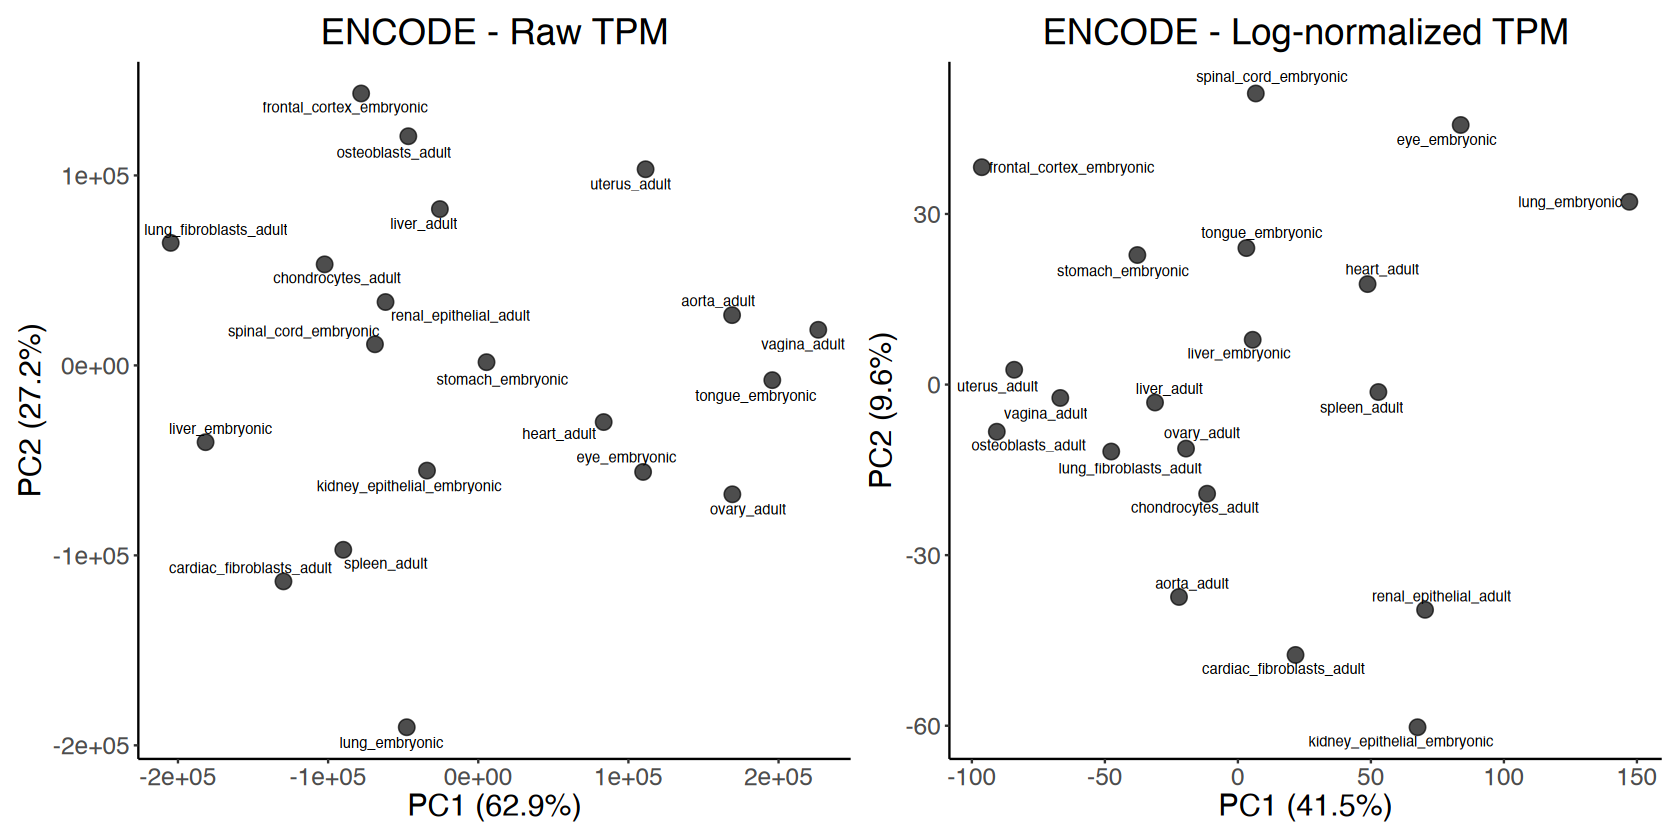

In [13]:
# Create combined plot
combined_plot <- p1 + p2

# change the size of the displayed plot
options(repr.plot.width=14, repr.plot.height=7)
print(combined_plot)

In [17]:
# Save the combined plot
ggsave(
    filename = file.path(out_dir, sprintf("ENCODE_PCA_TPM_comparison_%s.pdf", date)),
    plot = combined_plot,
    width = width * 0.6,
    height = width * 0.3, 
    units = "in", 
    dpi = dpi
)